In [1]:
#challenge
#Dataset

from sklearn.datasets import make_classification

X, y = make_classification(
    n_samples = 5000,
    n_features = 20,
    n_informative = 10,
    n_redundant = 5,
    random_state = 42
)

In [2]:
#Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    stratify = y,
    random_state = 42
)


In [4]:
#Train
from sklearn.ensemble import RandomForestClassifier

forest = RandomForestClassifier(
    n_estimators = 100,
    oob_score = True,
    random_state = 42,
    n_jobs = -1
)
forest.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [6]:
#Feature importance

import pandas as pd

importance = pd.Series(
    forest.feature_importances_,
    index = [
        f"feature_{i}"
        for i in range(X.shape[1])
    ]
)
importance = importance.sort_values(ascending = False)
print(importance)

feature_17    0.188398
feature_9     0.078255
feature_13    0.073335
feature_10    0.068082
feature_3     0.067136
feature_6     0.065922
feature_18    0.063873
feature_7     0.056091
feature_5     0.042284
feature_11    0.042235
feature_14    0.042106
feature_2     0.041425
feature_8     0.040655
feature_12    0.037425
feature_0     0.031791
feature_19    0.013015
feature_4     0.012873
feature_16    0.012042
feature_1     0.011687
feature_15    0.011371
dtype: float64


In [7]:
print(importance.head(3))

feature_17    0.188398
feature_9     0.078255
feature_13    0.073335
dtype: float64


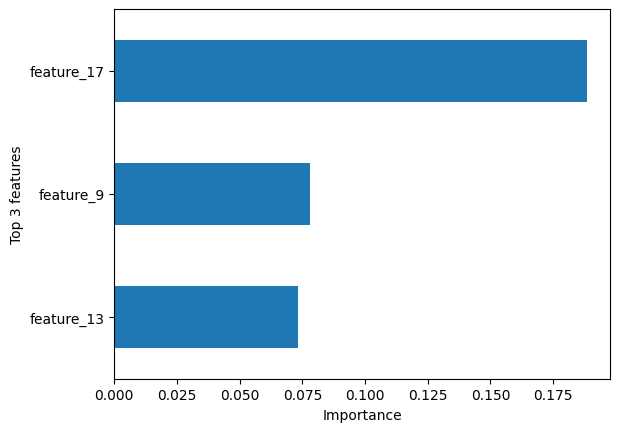

In [9]:
#Visualize
import matplotlib.pyplot as plt

importance.head(3).sort_values().plot(
    kind = 'barh'
)
plt.xlabel("Importance")
plt.ylabel("Top 3 features")
plt.show()

In [10]:
#OOB audit
print("OOB score:", forest.oob_score_)

OOB score: 0.94475


In [12]:
#Test accuracy

test_accuracy = forest.score(
    X_test,
    y_test
)
print("OOB:", forest.oob_score_)
print("Test:", test_accuracy)

OOB: 0.94475
Test: 0.955


In [15]:
#Cross Validation with 5 fold cv
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    forest,
    X_train,
    y_train,
    cv = 5,
    scoring = "accuracy"
)
print("CV scores:", cv_scores)
print("CV mean: ", cv_scores.mean())

CV scores: [0.9325  0.9575  0.945   0.9425  0.94625]
CV mean:  0.94475


In [16]:
#Variance test

from sklearn.tree import DecisionTreeClassifier

tree_scores = []

for seed in range(5):
    tree = DecisionTreeClassifier(
        random_state = seed
    )
    tree.fit(X_train, y_train)

    score = tree.score(
        X_test,
        y_test
    )

    tree_scores.append(score)



In [18]:
print(tree_scores)

import numpy as np

print("Mean: ", np.mean(tree_scores))
print("Std: ", np.std(tree_scores))

[0.872, 0.874, 0.875, 0.872, 0.879]
Mean:  0.8744
Std:  0.0025768197453450276


In [19]:
#now random forest
forest_scores = []

for seed in range(5):
    forest = RandomForestClassifier(
        n_estimators = 100,
        random_state = seed,
        n_jobs = -1
    )
    forest.fit(X_train, y_train)

    score = forest.score(
        X_test,
        y_test
    )
    forest_scores.append(score)

In [20]:
print("Mean from random forest: ", np.mean(forest_scores))
print("Standard deviation from random forest: ", np.std(forest_scores))

Mean from random forest:  0.9483999999999998
Standard deviation from random forest:  0.002332380757938122
